# Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
#--------------------------------
# for Kaggle/Colab
pio.renderers.default = "iframe"
#--------------------------------
# for Github
#pio.renderers.default = "png"

### Pandas Display Settings

In [2]:
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 200)
pd.options.display.float_format = '{:,.2f}'.format

# Load Data

In [3]:
file_path = "../student_mental_health_burnout_1M.csv"

try:
    # Step 1: Does the file path physically exist?
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found at the specified path: {file_path}")
    
    # Step 2: Attempt to read the file
    df_original = pd.read_csv(file_path)
    
    # Step 3: Check if the dataframe is empty
    if df_original.empty:
        raise ValueError("File read successfully, but the content is empty.")
    
    print(f"✅ Dataset loaded successfully. Number of rows: {df_original.shape[0]}")
    df = df_original.copy()

except FileNotFoundError as e:
    print(f"❌ Error: Please check the file path. \nDetails: {e}")

except pd.errors.EmptyDataError:
    print("❌ Error: The file is empty (EmptyDataError).")

except pd.errors.ParserError:
    print("❌ Error: Invalid file format. Please check the CSV delimiters (sep=',').")

except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

df_original.head()

✅ Dataset loaded successfully. Number of rows: 1000000


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.60,6.49,68.41,4.12,2.28,1.99,6.88,2.73,6.47,4.99,4.98,3.45,3.59,2.04,7.07,Low,1.75
1,20,Male,3,5.60,5.63,67.68,0.35,0.00,0.00,7.46,3.69,0.00,3.86,5.14,2.81,5.48,0.00,9.86,Low,0.00
2,29,Male,2,2.58,6.02,58.37,3.48,2.43,0.85,8.95,3.30,6.90,5.43,3.06,4.92,6.07,0.00,7.63,Low,0.70
3,27,Male,4,4.61,6.68,68.93,6.78,4.51,4.29,4.57,2.07,2.35,6.30,6.93,6.92,6.56,7.23,4.65,High,5.38
4,24,Male,4,2.19,4.01,69.14,1.85,1.10,0.00,5.99,4.03,4.51,4.90,5.13,4.38,5.93,0.00,8.93,Low,0.00


In [4]:
df = df_original.copy()

# Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [6]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,"1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00"
mean,23.00,2.50,5.00,6.00,71.00,4.25,2.99,1.27,6.50,3.01,5.00,5.02,5.04,5.00,5.98,1.78,7.02,1.32
std,3.74,1.12,1.99,1.55,5.66,1.68,1.51,1.22,1.47,1.46,1.98,1.96,2.16,1.98,1.96,1.66,1.31,1.34
min,17.00,1.00,0.00,1.00,42.37,0.00,0.00,0.00,3.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.31,0.00
25%,20.00,2.00,3.65,4.94,67.18,3.10,1.92,0.01,5.49,1.99,3.65,3.65,3.49,3.66,4.65,0.12,6.14,0.00
50%,23.00,3.00,5.00,6.00,71.00,4.24,2.97,1.05,6.50,3.00,5.00,5.00,5.00,5.00,6.00,1.50,7.07,1.01
75%,26.00,4.00,6.35,7.05,74.82,5.39,4.01,2.09,7.51,4.01,6.35,6.35,6.51,6.35,7.35,2.89,7.96,2.17
max,29.00,4.00,14.00,10.00,97.25,10.00,10.00,8.53,10.00,7.00,10.00,12.00,14.00,10.00,10.00,10.00,10.00,9.33


In [7]:
df["gender"].value_counts()

gender
Female    480070
Male      479643
Other      40287
Name: count, dtype: int64

In [8]:
df["risk_level"].value_counts()

risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64

# Duplicated Variables

In [9]:
df.duplicated().sum()

np.int64(0)

# Missing Values

In [10]:
def missing_values(data = df):
    missing_values = data.isna().sum().reset_index()
    missing_values.columns = ["Columns","Count"]
    missing_values["Percentage"] = (missing_values["Count"] * 100 )/ len(data)
    missing_values["Data Type"] = data.dtypes.to_list()
    
    return missing_values

In [11]:
missing_values(df)

,Columns,Count,Percentage,Data Type
0,age,0,0.00,int64
1,gender,0,0.00,object
2,academic_year,0,0.00,int64
3,study_hours_per_day,0,0.00,float64
4,exam_pressure,0,0.00,float64
5,academic_performance,0,0.00,float64
6,stress_level,0,0.00,float64
7,anxiety_score,0,0.00,float64
8,depression_score,0,0.00,float64
9,sleep_hours,0,0.00,float64


# Correlation

In [12]:
df_corr = df.select_dtypes(include = "number").corr()
df_corr

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
age,1.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00
academic_year,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
study_hours_per_day,-0.00,0.00,1.00,0.77,0.39,0.35,0.27,0.22,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.34,-0.34,0.19
exam_pressure,-0.00,0.00,0.77,1.00,0.13,0.46,0.35,0.28,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.43,-0.44,0.24
academic_performance,0.00,0.00,0.39,0.13,1.00,0.06,0.05,0.04,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.06,-0.06,0.03
stress_level,-0.00,0.00,0.35,0.46,0.06,1.00,0.76,0.62,-0.26,-0.17,-0.00,-0.00,-0.00,0.47,0.35,0.75,-0.95,0.55
anxiety_score,-0.00,0.00,0.27,0.35,0.05,0.76,1.00,0.48,-0.20,-0.13,-0.00,-0.00,-0.00,0.35,0.26,0.67,-0.87,0.46
depression_score,-0.00,0.00,0.22,0.28,0.04,0.62,0.48,1.00,-0.17,-0.11,-0.36,0.00,-0.00,0.29,0.21,0.64,-0.76,0.65
sleep_hours,-0.00,-0.00,-0.00,-0.00,-0.00,-0.26,-0.20,-0.17,1.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.37,0.25,-0.19
physical_activity,-0.00,-0.00,0.00,0.00,-0.00,-0.17,-0.13,-0.11,-0.00,1.00,0.00,0.00,0.00,-0.00,0.00,-0.11,0.17,-0.07


#### Correlation Matrix

In [13]:
fig = px.imshow(df_corr, 
                text_auto='.2f', 
                aspect="auto", 
                color_continuous_scale='Jet', 
                title="Correlation Heatmap")

fig.update_layout(
    width=1200,  
    height=800, 
    
   
    margin=dict(l=100, r=120, t=100, b=100), 
    coloraxis_colorbar=dict(
        title="Corr",
        thicknessmode="pixels", thickness=20,
        lenmode="fraction", len=0.8,
        x=1.05,
        y= 0.5
    )
)
fig.update_xaxes(side="bottom", tickangle= -45)
fig.update_layout(coloraxis_colorbar_x=1.05) 
fig.update_traces(xgap=2, ygap=2)

fig.show()

In [14]:
# We check nonlinear correlations using the Spearman (Ordered/Nonlinear) method instead of the Pearson (Linear) method.
df_spearman = df.select_dtypes(include = "number").corr(method='spearman')
fig = px.imshow(df_spearman, 
                text_auto='.2f', 
                aspect="auto", 
                color_continuous_scale= 'Jet',      #'RdBu_r' other color scale option
                title="Spearman Correlation Heatmap")

fig.update_layout(
    width=1200,   
    height=800,   
    
    margin=dict(l=100, r=120, t=100, b=100), 
    
    coloraxis_colorbar=dict(
        title="Corr",
        thicknessmode="pixels", thickness=20,
        lenmode="fraction", len=0.8,
        x=1.05,
        y= 0.5
    )
)

fig.update_xaxes(side="bottom", tickangle= -45)
fig.update_traces(xgap=2, ygap=2)
fig.update_layout(coloraxis_colorbar_x=1.05) 

fig.show()

#### Statistical Relationship Between Attributes and Dropout Risk

In [15]:
def find_common_correlations(df, target_col="dropout_risk", method = "spearman"):
    correlations = df.select_dtypes(include=[np.number]).corr(method = method)[target_col].sort_values(ascending=False)
    
    corr_df = correlations.to_frame(name="Correlation with Dropout Risk")
    return corr_df

risk_correlations = find_common_correlations(df)
risk_correlations

,Correlation with Dropout Risk
dropout_risk,1.00
burnout_score,0.66
depression_score,0.62
stress_level,0.55
anxiety_score,0.45
financial_stress,0.41
exam_pressure,0.23
study_hours_per_day,0.18
family_expectation,0.13
academic_performance,0.03


#### Plot Style

In [16]:
from matplotlib.colors import LinearSegmentedColormap
sns.set_style("white", {
    "axes.facecolor": "#FAFAFA",  
    "figure.facecolor": "#FFFFFF", 
    "grid.color": "#F0F0F0",       
    "axes.edgecolor": "#D1D1D1",   
    "text.color": "#333333"        
})

colors = ["#E0E0E0", "#4169E1", "#FF4B2B"] 
soft_modern_cmap = LinearSegmentedColormap.from_list("soft_tech", colors, N=256)

#### Depression Level vs Dropout Risk

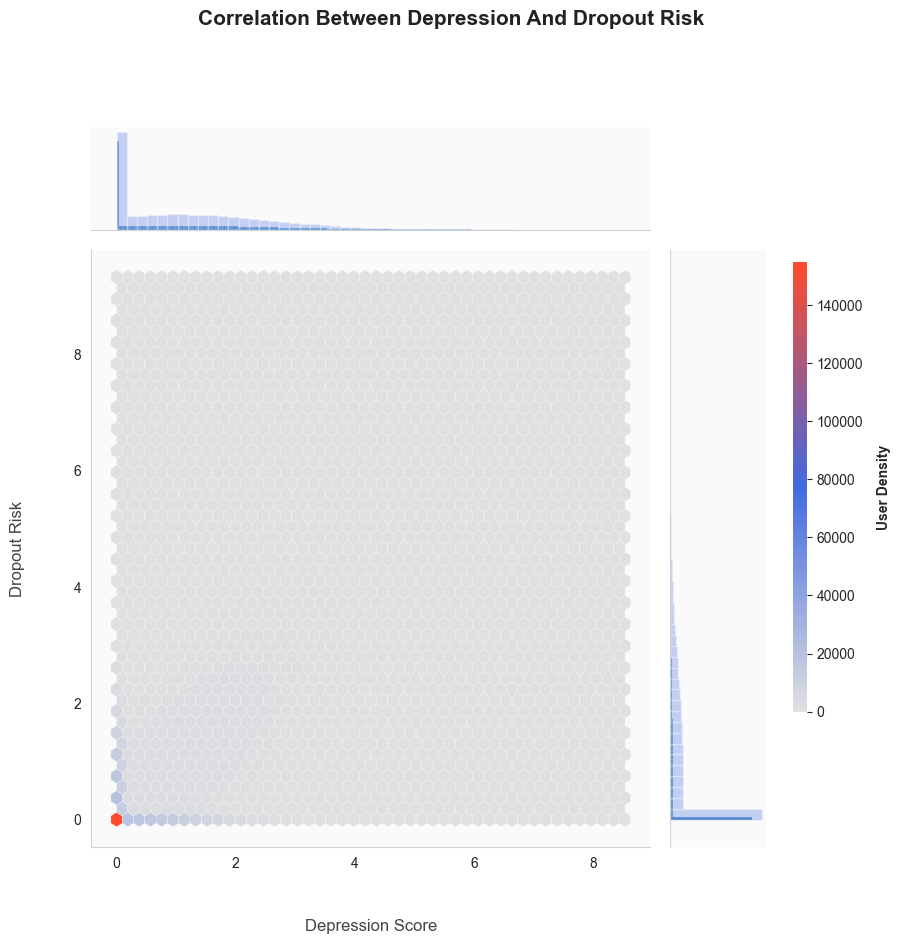

In [17]:
g = sns.jointplot(data=df, x="depression_score", y="dropout_risk", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Depression Score", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Dropout Risk", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["depression_score"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["dropout_risk"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Depression And Dropout Risk", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Screen Time vs Interner Usage

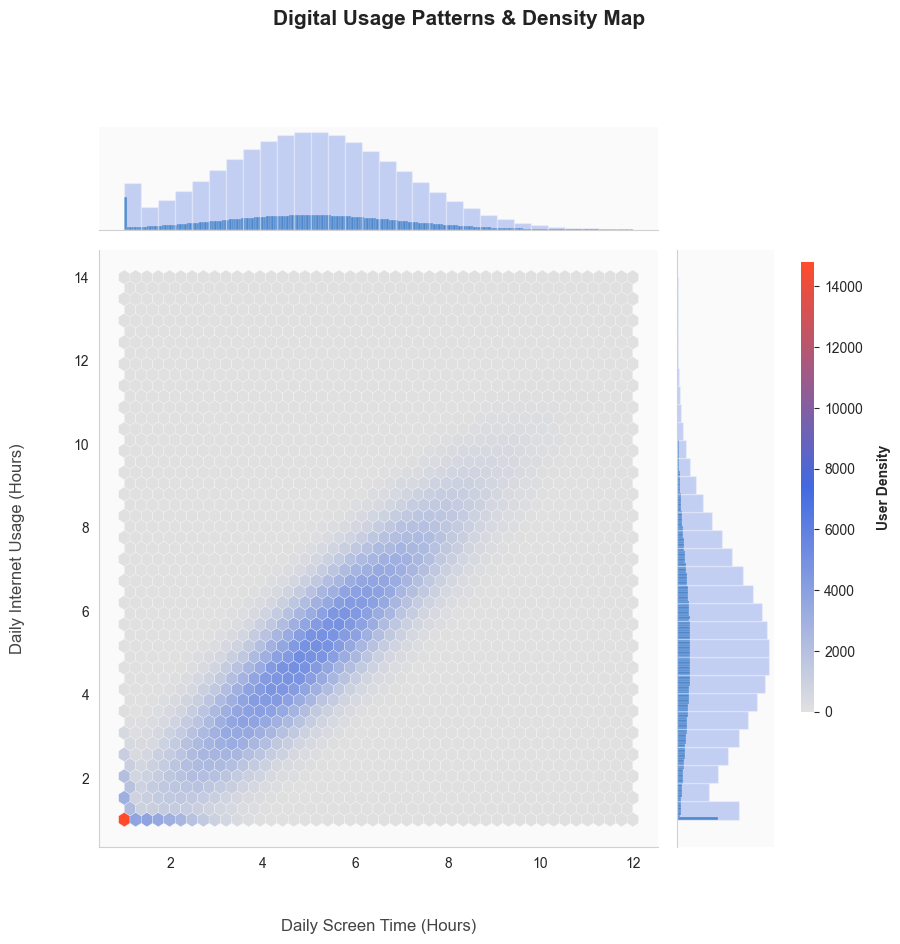

In [18]:
g = sns.jointplot(data=df, x="screen_time", y="internet_usage", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Daha ince bir bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Barın dış çizgisini kaldır

#LABELS
g.ax_joint.set_xlabel("Daily Screen Time (Hours)", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Daily Internet Usage (Hours)", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["screen_time"], color="#4169E1", alpha=0.3, bins=30, edgecolor='white')
g.ax_marg_y.hist(df["internet_usage"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=30, edgecolor='white')

# TITLE
g.fig.suptitle("Digital Usage Patterns & Density Map", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Burnout Level vs Stress Level

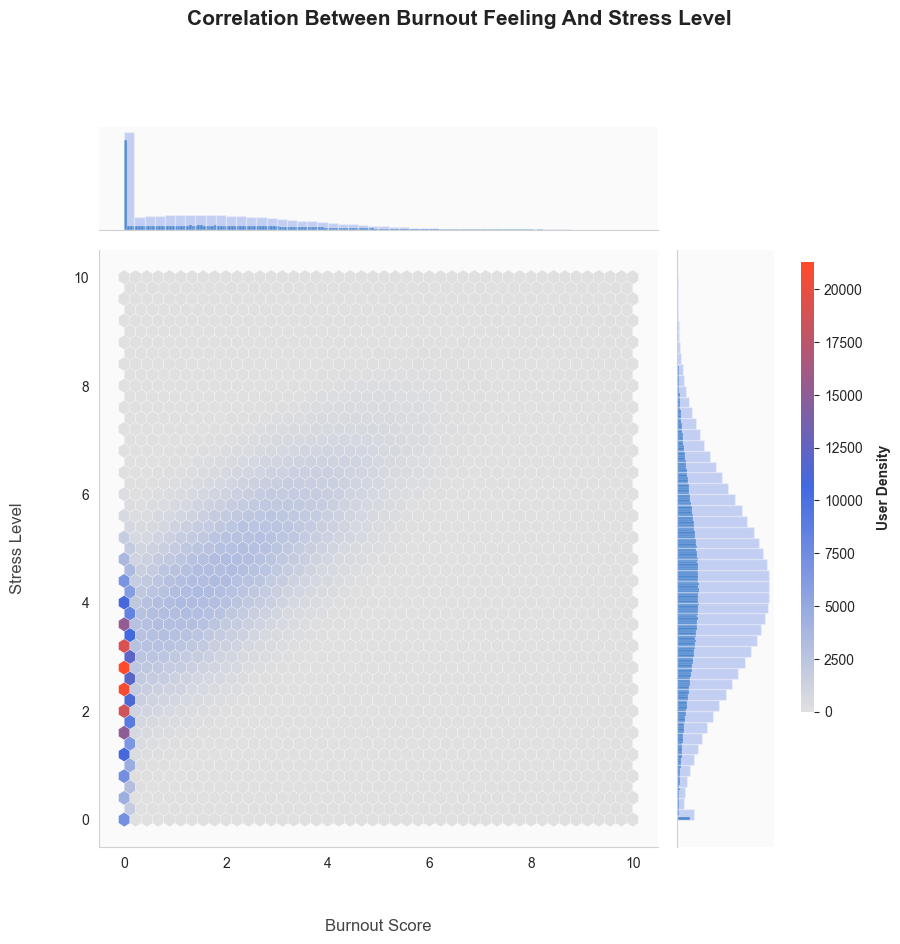

In [19]:
g = sns.jointplot(data=df, x="burnout_score", y="stress_level", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Burnout Score", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Stress Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["burnout_score"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["stress_level"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Burnout Feeling And Stress Level", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Social Support vs Depression Level

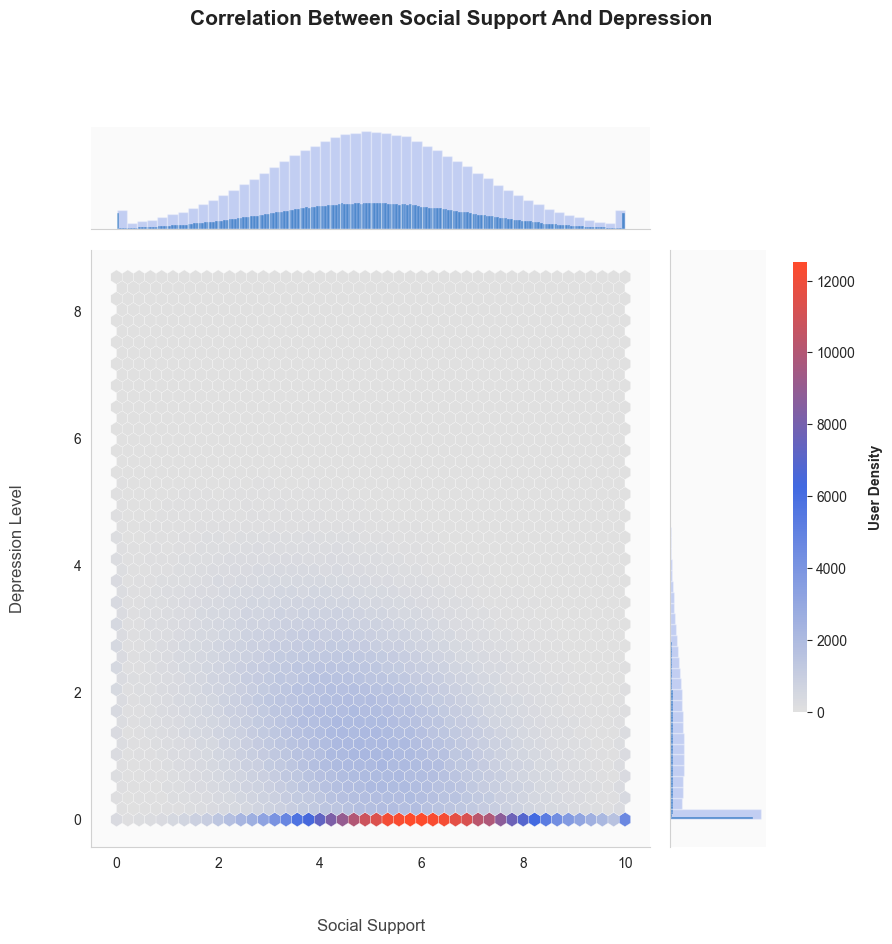

In [20]:
g = sns.jointplot(data=df, x="social_support", y="depression_score", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Social Support", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Depression Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["social_support"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["depression_score"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Social Support And Depression", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Social Support vs Dropout Risk

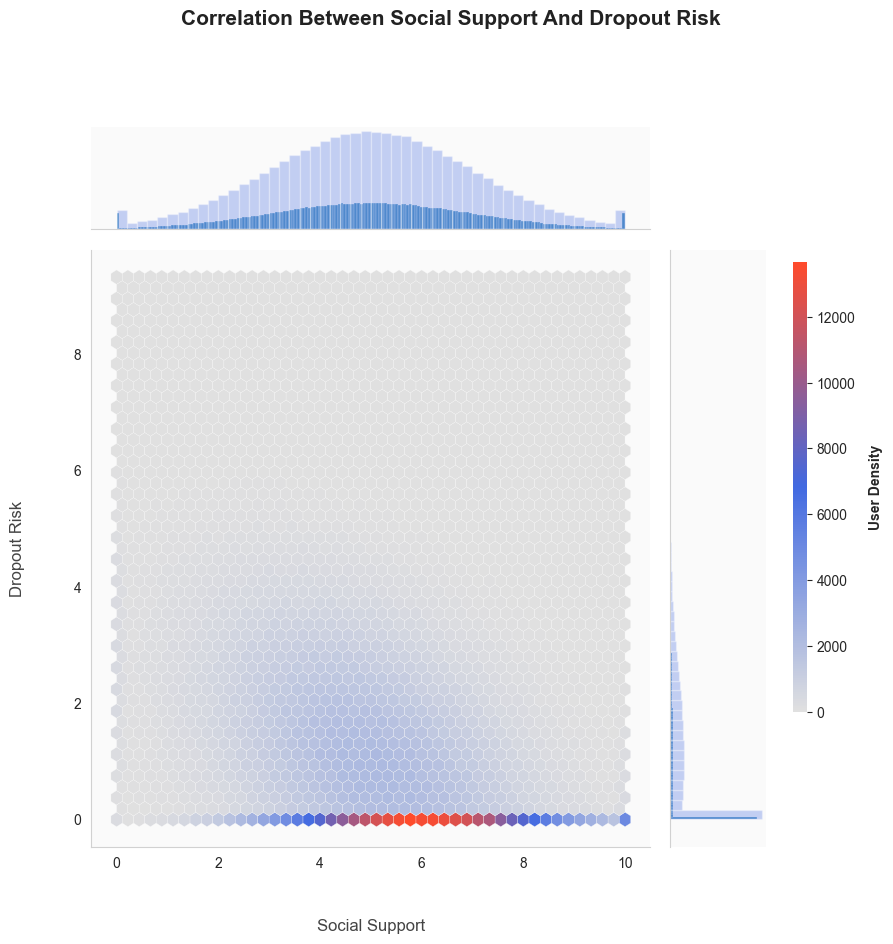

In [21]:
g = sns.jointplot(data=df, x="social_support", y="dropout_risk", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Social Support", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Dropout Risk", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["social_support"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["depression_score"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Social Support And Dropout Risk", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()


#### Financial Stress vs Stress Level

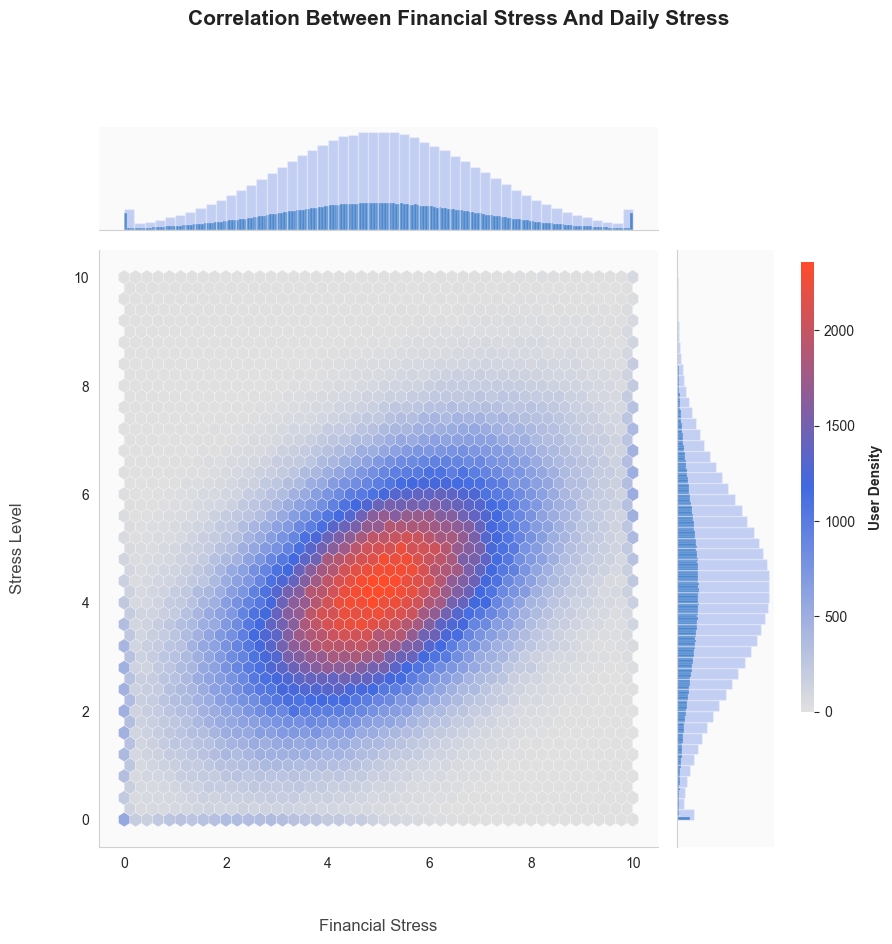

In [22]:
g = sns.jointplot(data=df, x="financial_stress", y="stress_level", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Financial Stress", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Stress Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["financial_stress"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["stress_level"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Financial Stress And Daily Stress", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

#### Financial Stress vs Dropout Risk

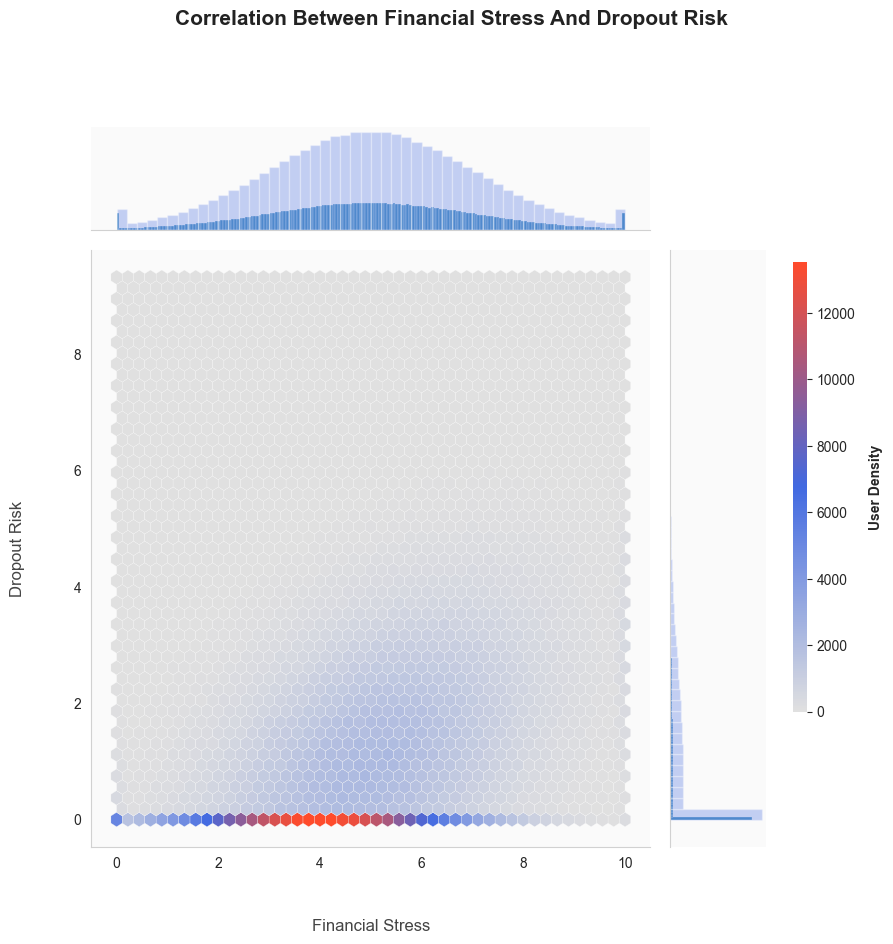

In [23]:
g = sns.jointplot(data=df, x="financial_stress", y="dropout_risk", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Financial Stress", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Dropout Risk", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["financial_stress"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["dropout_risk"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Correlation Between Financial Stress And Dropout Risk", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

# 🔍 Correlation Analysis & Feature Insights

This section evaluates the relationships between the feature set and the target variable, **dropout_risk**. By comparing **Pearson** (linear) and **Spearman** (rank-based) correlation coefficients, we have identified the primary psychological, social, and economic drivers of student attrition.

### 1. Key Drivers of Dropout Risk
The analysis reveals a multi-dimensional risk profile where psychological distress and financial instability are the dominant predictors.

| Variable | Correlation (Pearson/Spearman) | Impact Type |
| :--- | :---: | :--- |
| **Burnout Score** | +0.69 | Strong Positive (Primary Driver) |
| **Depression Score** | +0.65 | Strong Positive |
| **Mental Health Index** | -0.63 | Strong Negative (Protective Factor) |
| **Financial Stress** | +0.58 | Moderate-Strong Positive |
| **Stress Level** | +0.55 | Moderate Positive |
| **Social Support** | -0.39 | Moderate Negative |

**Key Insight:** Students are not merely "failing out" due to grades; they are being forced out by a combination of **mental health exhaustion** and **economic pressure**. The high correlation of *Financial Stress* suggests that tuition or cost-of-living concerns act as a significant catalyst for dropout risk.



---

### 2. The "Irrelevant" Features (Noise Detection)
Several variables showed near-zero correlation ($|r| < 0.05$) with dropout risk. These features suggest that, within this specific population, risk is independent of:

* **Demographics & Time:** `age` and `academic_year`.
* **Digital Lifestyle:** `screen_time` and `internet_usage`.
* **Academic Baseline:** Interestingly, `academic_performance` shows a very weak link.

> **Senior Observation:** High academic performance does not insulate a student from risk if psychological and financial stressors are high. Success in the classroom does not equate to stability in enrollment.

---

### 3. Multicollinearity & Redundancy
To optimize model efficiency and prevent overfitting, we identified the following highly collinear pairs:

* **Stress Level vs. Mental Health Index (-0.95):** These are nearly perfect inverses. Including both would introduce redundancy.
* **Screen Time vs. Internet Usage (+0.89):** These variables capture the same behavioral pattern.
* **Burnout Score vs. Depression Score (+0.82):** High overlap indicates these features may be measuring the same underlying psychological exhaustion.

---

### 4. Strategic Recommendations for Modeling
Based on these statistical insights, the following data strategy is recommended:

1.  **Feature Pruning:** Drop `age`, `academic_year`, and `screen_time`. These variables contribute noise rather than signal.
2.  **Dimensionality Reduction:** Consider an interaction term between `Financial Stress` and `Social Support`, as these likely moderate each other's impact.
3.  **Priority Interventions:** Strategy should shift from "Academic Tutoring" to **"Financial Aid & Mental Health Counseling,"** as these domains show the highest statistical impact on retention.
4.  **Model Selection:** Since Spearman and Pearson coefficients are nearly identical, the relationships are largely linear. We can confidently utilize **Logistic Regression** as a baseline, though **Tree-based models** (like XGBoost) may better capture complex interactions.

# Outliers

In [24]:
numeric_cols = df.select_dtypes(include=['number']).columns
df_sample = df.sample(frac=0.1, random_state=42)
n_cols = 2
n_rows = (len(numeric_cols) + 1) // 2 # Automatically calculates rows based on column number.

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=numeric_cols,
    vertical_spacing=0.02, 
    horizontal_spacing=0.1
)

for index, col_name in enumerate(numeric_cols):
    row = (index // n_cols) + 1
    col = (index % n_cols) + 1
    
    fig.add_trace(
        go.Box(
            y=df_sample[col_name], 
            name="", # Prevents name clutter on the X-axis
            marker_color='royalblue', 
            boxmean=True, # Adds an average line (dashed line)
            boxpoints='outliers', # Only displays extreme values as decimal points.
            quartilemethod="linear"
        ),
        row=row, col=col
    )

fig.update_layout(
    height=300 * n_rows, # Adjusts height according to row count
    width=900,
    title_text="Outlier Analysis",
    title_x=0.5,
    showlegend=False,
    template="plotly_white"
)

fig.show()

In [25]:
df_sample = df.sample(frac=0.01, random_state=42)
numeric_cols = df_sample.select_dtypes(include="number").columns.tolist()

# Exclude target variable from the list to avoid self-correlation plot
target = 'dropout_risk'
features = [col for col in numeric_cols if col != target]

# Dynamic Subplot Structure
rows = (len(features) + 1) // 2
fig = make_subplots(
    rows=rows, cols=2,
    subplot_titles=features,
    vertical_spacing=0.04, 
    horizontal_spacing=0.08
)

# Adding Scatter Plots with Loop
for index, col_name in enumerate(features):
    row = (index // 2) + 1
    col = (index % 2) + 1
    
    fig.add_trace(
        go.Scatter(
            x=df_sample[col_name],      # Feature on X-axis (e.g., Stress)
            y=df_sample[target],        # Risk score on Y-axis
            mode='markers',
            name=col_name,
            marker=dict(
                size=4, 
                opacity=0.4,            # Transparency is essential to visualize density
                color='royalblue',
                line=dict(width=0)      # No borders for a cleaner look
            )
        ),
        row=row, col=col
    )

# Layout Adjustments
fig.update_layout(
    height=350 * rows, 
    width=1000,
    title_text="<b>Feature Analysis: Relationship with Dropout Risk</b>",
    title_x=0.5,
    title_font_size=22,
    showlegend=False,
    template="plotly_white",
    margin=dict(t=120, b=50, l=50, r=50)
)

# Improve axis readability
fig.update_xaxes(showgrid=True, gridcolor='whitesmoke')
fig.update_yaxes(title_text="Risk Score", showgrid=True, gridcolor='whitesmoke')

fig.show()

In [26]:
def data_distribution_stats(data=df):
    numeric_df = data.select_dtypes(include=[np.number])
    cols = numeric_df.columns
    
    np_data = numeric_df.values
    
    means = np.nanmean(np_data, axis=0) 
    skews = skew(np_data, axis=0, nan_policy='omit')
    kurtos = kurtosis(np_data, axis=0, nan_policy='omit')
    
    stats_df = pd.DataFrame({
        "Columns": cols,
        "Mean": means,
        "Skew": skews,
        "Kurtosis": kurtos
    })
    
    return stats_df.reset_index(drop=True)


dist_stats = data_distribution_stats(df)
dist_stats

,Columns,Mean,Skew,Kurtosis
0,age,23.00,0.00,-1.21
1,academic_year,2.50,-0.00,-1.36
2,study_hours_per_day,5.00,0.04,-0.12
3,exam_pressure,6.00,-0.02,-0.16
4,academic_performance,71.00,-0.00,-0.00
5,stress_level,4.25,0.03,-0.14
6,anxiety_score,2.99,0.15,-0.28
7,depression_score,1.27,0.84,0.09
8,sleep_hours,6.50,-0.00,-0.33
9,physical_activity,3.01,0.09,-0.35


In [27]:
def outlier_analysis(data=df):
    
    numeric_df = data.select_dtypes(include=[np.number])
    outlier_list = []
    total_rows = len(data)

    for col in numeric_df.columns:
        # Quartile calculation with NumPy (For speed)
        q1 = np.nanpercentile(data[col], 25)
        q3 = np.nanpercentile(data[col], 75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Let's count those outside the borders
        lower_outliers = np.sum(data[col] < lower_bound)
        upper_outliers = np.sum(data[col] > upper_bound)
        total_outliers = lower_outliers + upper_outliers
        percentage = (total_outliers / total_rows) * 100
        
        outlier_list.append({
            "Column": col,
            "Lower Outliers": lower_outliers,
            "Upper Outliers": upper_outliers,
            "Total Outliers": total_outliers,
            "Percentage (%)": round(percentage, 4)
        })
    
   
    return pd.DataFrame(outlier_list)

outlier_df = outlier_analysis(df)
outlier_df

,Column,Lower Outliers,Upper Outliers,Total Outliers,Percentage (%)
0,age,0,0,0,0.00
1,academic_year,0,0,0,0.00
2,study_hours_per_day,0,3491,3491,0.35
3,exam_pressure,2809,0,2809,0.28
4,academic_performance,3471,3473,6944,0.69
5,stress_level,0,3287,3287,0.33
6,anxiety_score,0,3409,3409,0.34
7,depression_score,0,3351,3351,0.34
8,sleep_hours,0,0,0,0.00
9,physical_activity,0,0,0,0.00


# Asking Question About Data

- Distribution of school dropout risk by gender
- Statistical table of mental states by gender
- Risk Level Distribution
- Mental Health Metrics by Risk Level (Mean Values)
- Impact of Sleep Duration on Stress Levels
- Distribution Of Academic Performance


In [28]:
mental_condition_map = ["stress_level","anxiety_score","depression_score","burnout_score","mental_health_index"]

In [29]:
df_sample = df.sample(frac=0.05, random_state=42)
fig = px.histogram(df_sample, x="dropout_risk", y= "dropout_risk", color="gender", marginal="rug",
                   hover_data=df.columns)
fig.show()

In [30]:
df.groupby(by ="gender")[mental_condition_map].agg(['min','max','mean']).T

gender                    Female  Male  Other
stress_level        min     0.00  0.00   0.00
                    max    10.00 10.00  10.00
                    mean    4.25  4.25   4.24
anxiety_score       min     0.00  0.00   0.00
                    max    10.00  9.50   9.65
                    mean    2.99  2.99   2.97
depression_score    min     0.00  0.00   0.00
                    max     7.86  8.53   7.13
                    mean    1.28  1.27   1.27
burnout_score       min     0.00  0.00   0.00
                    max    10.00 10.00   9.60
                    mean    1.78  1.78   1.78
mental_health_index min     1.32  1.31   1.51
                    max    10.00 10.00  10.00
                    mean    7.02  7.02   7.03

In [31]:
df_financial = df.groupby(by = "risk_level")["financial_stress"]\
                 .mean()\
                 .reset_index()
df_financial.columns = ["risk_level", "mean_value"]
df_financial

,risk_level,mean_value
0,High,6.54
1,Low,4.76
2,Medium,5.76


In [32]:
fig = px.bar(df_financial, x="risk_level", y="mean_value")
fig.update_traces(marker_color='royalblue')

fig.show()

In [33]:

df_mental_condition = df.sort_values(by = "risk_level", ascending = True)\
.groupby(by = "risk_level")[mental_condition_map]\
.agg("mean")\
.rename_axis(None, axis=0)
df_mental_condition.T

,High,Low,Medium
stress_level,7.58,3.71,5.88
anxiety_score,5.67,2.56,4.30
depression_score,3.66,0.93,2.33
burnout_score,6.73,1.04,4.04
mental_health_index,4.16,7.47,5.66


In [34]:
df_sample = df.sample(frac=0.05, random_state=42)
df_mental_condition = df_sample.groupby("risk_level")[mental_condition_map]\
    .mean()\
    .reindex(["Low", "Medium", "High"]) # We arrange the categories in a logical order.

fig = go.Figure()

# Categories (X-axis): Low, Medium, High
categories = df_mental_condition.index

# We add a bar for each metric (stress_level, anxiety_score, etc.)
for metric in df_mental_condition.columns:
    fig.add_trace(go.Bar(
        x = categories,
        y = df_mental_condition[metric],
        name = metric.replace("_", " ").title(),
        text = df_mental_condition[metric].round(2), # Write the values on the bar.
        textposition = 'auto'
    ))

fig.update_layout(
    title = "Mental Health Metrics by Risk Level (Mean Values)",
    xaxis_title = "Student Risk Level",
    yaxis_title = "Average Score",
    barmode = 'group', 
    template = "plotly_white",
    legend_title = "Metrics",
    hovermode = "x unified"
)

fig.show()

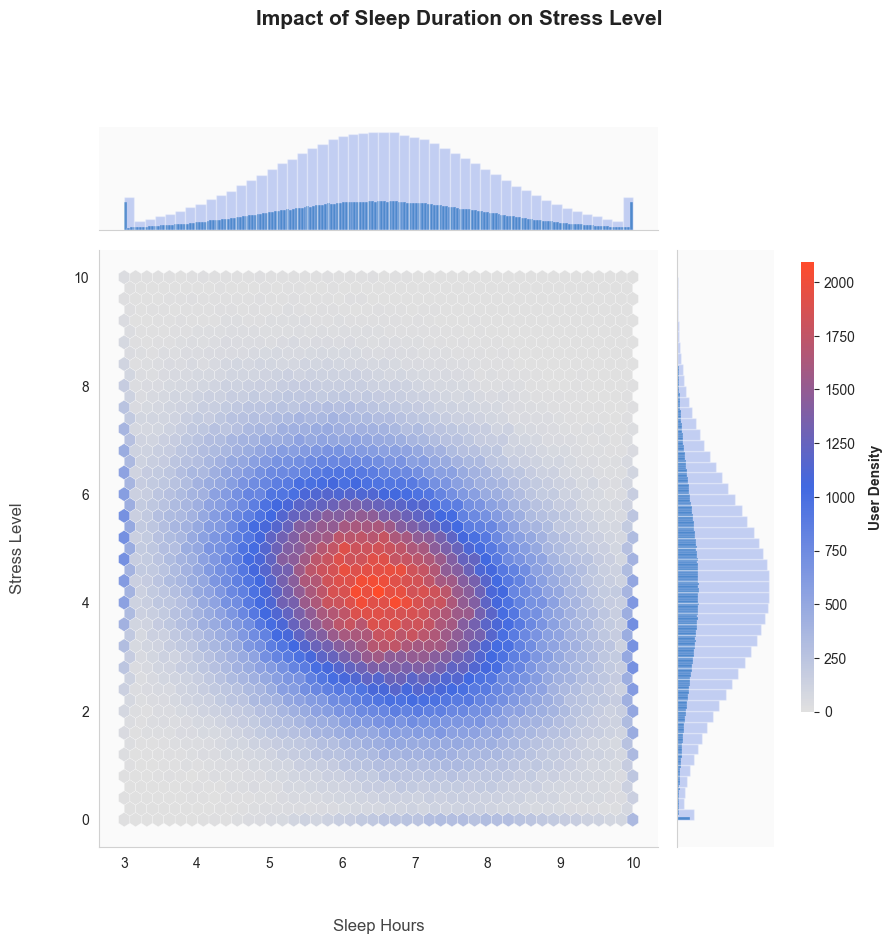

In [35]:
g = sns.jointplot(data=df, x="sleep_hours", y="stress_level", 
                  kind="hex", cmap=soft_modern_cmap, height=9,
                  joint_kws=dict(gridsize=45, edgecolors="#FAFAFA", linewidths=0.2))

#COLORBAR
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
cbar_ax = g.fig.add_axes([.88, .25, .015, .5]) # Thinner bar
cbar = plt.colorbar(cax=cbar_ax)
cbar.set_label("User Density", fontsize=10, labelpad=10, fontweight='bold')
cbar.outline.set_visible(False) # Remove outline of colorbar

#LABELS
g.ax_joint.set_xlabel("Sleep Hours", labelpad=35, fontsize=12, color="#444444")
g.ax_joint.set_ylabel("Stress Level", labelpad=35, fontsize=12, color="#444444")

#EDGE HISTOGRAMS 
g.ax_marg_x.hist(df["sleep_hours"], color="#4169E1", alpha=0.3, bins=50, edgecolor='white')
g.ax_marg_y.hist(df["stress_level"], orientation='horizontal', color="#4169E1", alpha=0.3, bins=50, edgecolor='white')

#TITLE
g.fig.suptitle("Impact of Sleep Duration on Stress Level", 
               y=1.03, fontsize=15, fontweight='bold', color="#222222")

plt.show()

In [36]:
df_sample = df.sample(frac=0.01, random_state=42)
fig = go.Figure(data = px.histogram(df_sample["academic_performance"]))
fig.show()